In [2]:
from google.colab import files         ##importing csv file googlecolab
uploaded=files.upload()

Saving Diab.csv to Diab.csv


In [11]:
##importing all the function which are used
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,ShuffleSplit
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,roc_auc_score,confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('Diab.csv')
df.head()

,Pat_Id,Gender,OGTT,DBP,BMI,Age,Diabetic
0,101,Male,176,90,33.7,58,Yes
1,102,Male,150,66,34.7,42,No
2,103,Male,73,50,23.0,21,No
3,104,Female,187,68,37.7,41,Yes
4,105,Female,100,88,46.8,31,No


In [5]:

df_continuous=df.iloc[:,2:6]
df_categorical=df[['Diabetic','Gender']]
df_categorical.head()

,Diabetic,Gender
0,Yes,Male
1,No,Male
2,No,Male
3,Yes,Female
4,No,Female


In [6]:
SS=StandardScaler()
SS_X=SS.fit_transform(df_continuous)
SS_X=pd.DataFrame(SS_X,columns=df_continuous.columns)
SS_X.head()


,OGTT,DBP,BMI,Age
0,1.806312,1.512904,0.191222,2.133749
1,0.957604,-0.537564,0.334117,0.769678
2,-1.555878,-1.904543,-1.337752,-1.020667
3,2.165380,-0.366692,0.762801,0.684423
4,-0.674527,1.342031,2.063143,-0.168122


In [7]:
LE=LabelEncoder()
df_categorical=df_categorical.copy()
df_categorical["Gender_LE"]=LE.fit_transform(df_categorical['Gender'])
df_categorical["Diabetic_LE"]=LE.fit_transform(df_categorical['Diabetic'])
df_categorical.head()

,Diabetic,Gender,Gender_LE,Diabetic_LE
0,Yes,Male,1,1
1,No,Male,1,0
2,No,Male,1,0
3,Yes,Female,0,1
4,No,Female,0,0


In [17]:
X_Train,X_Test,Y_Train,Y_Test=train_test_split(SS_X,df_categorical['Diabetic_LE'],test_size=0.2,random_state=42)
model=LogisticRegression()
model.fit(X_Train,Y_Train)
Y_pred_test=model.predict(X_Test)
Y_pred_train=model.predict(X_Train)
Testing_Accuracy=accuracy_score(Y_Test,Y_pred_test)
Training_Accuracy=accuracy_score(Y_Train,Y_pred_train)
print("Testing Accuracy: ",Testing_Accuracy)
print("Training Accuracy: ",Training_Accuracy)
Model_output=Y_pred_test
print(Model_output)

Testing Accuracy:  0.76
Training Accuracy:  0.7725
[1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0
 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 1 1 0 0 1 0 0 0 0]


In [18]:
conf_matrix=confusion_matrix(Y_Test,Y_pred_test)
print("Confusion matrix: ",conf_matrix)
Accuracy=accuracy_score(Y_Test,Y_pred_test)
print("Accuracy: ",Accuracy)
Precision=precision_score(Y_Test,Y_pred_test)
print("Precision: ",Precision)
Recall=recall_score(Y_Test,Y_pred_test)
print("Recall: ",Recall)
F1_Score=f1_score(Y_Test,Y_pred_test)
print("F1 Score: ",F1_Score)

Confusion matrix:  [[62  8]
 [16 14]]
Accuracy:  0.76
Precision:  0.6363636363636364
Recall:  0.4666666666666667
F1 Score:  0.5384615384615384


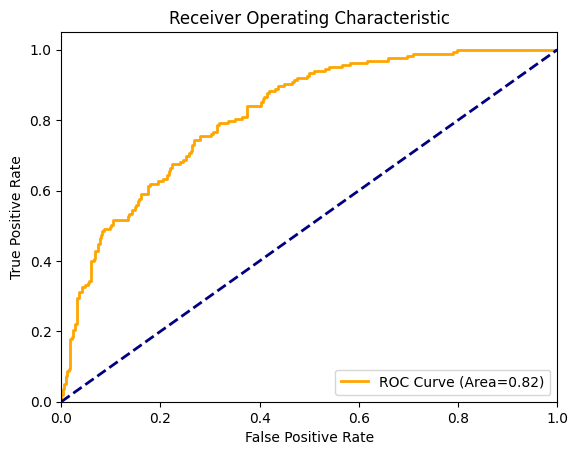

roc_auc_score 0.8179534324880304


In [21]:
from sklearn.metrics import roc_curve,auc
predictions=model.predict(SS_X)
y_pred_probability=model.predict_proba(SS_X)[:,1]
fpr,tpr,thresholds=roc_curve(df_categorical['Diabetic_LE'],y_pred_probability)
roc_auc=auc(fpr,tpr)
plt.figure()
plt.plot(fpr,tpr,color="Orange",lw=2,label="ROC Curve (Area=%0.2f)"%roc_auc)
plt.plot([0,1],[0,1],color='navy',lw=2,linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()
print("roc_auc_score",roc_auc)